# SpikingDiffusion: Spike-Based Audio Denoising with Hybrid Neural Architectures

This notebook presents a diffusion-inspired audio denoising framework using:

- Spiking Neural Networks (SNNs)
- Rate-coded spike encoding
- Anscombe variance stabilization
- Hybrid spike-continuous neural decoding
- Real speech waveform reconstruction

The model performs noisy-to-clean waveform reconstruction on real speech samples from the Speech Commands dataset.

# Import Required Libraries

The following libraries are used for:

- Deep learning with PyTorch
- Audio processing using torchaudio
- Spiking neural network simulation using snnTorch
- Visualization and waveform analysis

In [48]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

from torch.utils.data import DataLoader, Subset

import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate

# Experiment Parameters

The following parameters define:

- Audio waveform length
- Number of spike simulation timesteps
- Batch size
- Training epochs
- Audio sampling rate

In [49]:
L = 4000

num_steps = 40

epochs = 20

batch_size = 128

sr = 16000

# Anscombe Variance Stabilization

The Anscombe transform stabilizes variance in noisy signals and converts signal-dependent noise into a more Gaussian-like form.

Forward transform:

In [50]:
def anscombe(x):

    return 2.0 * torch.sqrt(
        x + 3.0 / 8.0
    )

def inverse_anscombe(y):

    return ((y / 2.0) ** 2) - 3.0 / 8.0

# Speech Commands Dataset

The Speech Commands dataset contains short spoken words and is widely used for speech recognition and audio learning experiments.

A subset of 500 samples is used for lightweight experimentation and rapid prototyping.

In [51]:
os.makedirs("./data", exist_ok=True)

dataset = torchaudio.datasets.SPEECHCOMMANDS(
    root="./data",
    download=True
)

subset = Subset(
    dataset,
    range(500)
)

print("Subset Size:", len(subset))

Subset Size: 500


# Audio Preprocessing Pipeline

The preprocessing pipeline performs:

1. Audio resampling
2. Mono conversion
3. Waveform padding/truncation
4. Min-max normalization
5. Anscombe transformation
6. Gaussian corruption
7. Shared normalization scaling

The final output contains:
- Noisy transformed waveform
- Clean transformed waveform
- Original clean waveform

In [52]:
class AudioDataset(torch.utils.data.Dataset):

    def __init__(self, subset):

        self.subset = subset

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, idx):

        waveform, sample_rate, label, *_ = self.subset[idx]

        # ====================================================
        # RESAMPLE IF NEEDED
        # ====================================================

        if sample_rate != 16000:

            waveform = torchaudio.functional.resample(
                waveform,
                sample_rate,
                16000
            )

        # ====================================================
        # MONO AUDIO
        # ====================================================

        waveform = waveform.mean(dim=0)

        # ====================================================
        # FIX LENGTH
        # ====================================================

        if waveform.shape[0] < L:

            pad = L - waveform.shape[0]

            waveform = F.pad(
                waveform,
                (0, pad)
            )

        else:

            waveform = waveform[:L]

        # ====================================================
        # NORMALIZE TO [0,1]
        # ====================================================

        waveform = (
            waveform - waveform.min()
        ) / (
            waveform.max() - waveform.min() + 1e-8
        )

        clean = waveform.clone()

        # ====================================================
        # ANSCOMBE TRANSFORM
        # ====================================================

        clean_ans = anscombe(clean)

        # ====================================================
        # ADD GAUSSIAN NOISE
        # ====================================================

        noise_strength = np.random.uniform(
            0.08,
            0.25
        )

        noisy_ans = clean_ans + (
            noise_strength *
            torch.randn_like(clean_ans)
        )

        # ====================================================
        # IMPORTANT FIX:
        # SAME SCALING FOR BOTH
        # ====================================================

        noisy_ans = torch.clamp(
            noisy_ans,
            0,
            3
        )

        clean_ans = torch.clamp(
            clean_ans,
            0,
            3
        )

        noisy_ans = noisy_ans / 3.0

        clean_ans = clean_ans / 3.0

        return noisy_ans, clean_ans, clean

# DataLoader Construction

The DataLoader enables mini-batch loading and randomized sampling during training.

In [53]:
audio_dataset = AudioDataset(subset)

loader = DataLoader(
    audio_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Dataset size:", len(audio_dataset))

Dataset size: 500


# Hybrid Spiking Denoiser Architecture

The model consists of:

## Spike-Based Encoder
- Fully connected layers
- Leaky Integrate-and-Fire neurons
- Temporal spike processing

## Continuous Decoder
- Dense reconstruction layers
- Continuous waveform recovery

The architecture combines:
- Neuromorphic temporal encoding
- Continuous signal reconstruction

In [54]:
class HybridSpikingDenoiser(nn.Module):

    def __init__(
        self,
        input_dim=4000,
        hidden1=2048,
        hidden2=1024,
        hidden3=512,
        beta=0.97
    ):

        super().__init__()

        # ====================================================
        # SPIKING ENCODER
        # ====================================================

        self.fc1 = nn.Linear(
            input_dim,
            hidden1
        )

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(
            hidden1,
            hidden2
        )

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc3 = nn.Linear(
            hidden2,
            hidden3
        )

        self.lif3 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        # ====================================================
        # CONTINUOUS DECODER
        # ====================================================

        self.fc4 = nn.Linear(
            hidden3,
            hidden2
        )

        self.fc5 = nn.Linear(
            hidden2,
            hidden1
        )

        self.fc6 = nn.Linear(
            hidden1,
            input_dim
        )

    def forward(self, spike_input):

        Tsteps, B, D = spike_input.shape

        mem1 = self.lif1.init_leaky()

        mem2 = self.lif2.init_leaky()

        mem3 = self.lif3.init_leaky()

        outputs = []

        for step in range(Tsteps):

            x = spike_input[step]

            # =================================================
            # SPIKING ENCODER
            # =================================================

            cur1 = self.fc1(x)

            spk1, mem1 = self.lif1(
                cur1,
                mem1
            )

            cur2 = self.fc2(spk1)

            spk2, mem2 = self.lif2(
                cur2,
                mem2
            )

            cur3 = self.fc3(spk2)

            spk3, mem3 = self.lif3(
                cur3,
                mem3
            )

            # =================================================
            # CONTINUOUS DECODER
            # =================================================

            x = F.relu(
                self.fc4(mem3)
            )

            x = F.relu(
                self.fc5(x)
            )

            out = self.fc6(x)

            outputs.append(out)

        return torch.mean(
            torch.stack(outputs),
            dim=0
        )

# Model Initialization

The model is initialized along with:
- AdamW optimizer
- Mean Squared Error loss

In [55]:
model = HybridSpikingDenoiser(
    input_dim=L
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

# Training Procedure

Training steps:

1. Convert waveform into spike trains using rate coding
2. Perform temporal spike-based encoding
3. Reconstruct denoised waveform
4. Compute reconstruction loss
5. Update network parameters

Gradient clipping is applied for training stability.

In [56]:
from tqdm import tqdm
loss_history = []

print("Starting training...\n")

for epoch in range(epochs):

    model.train()

    total_loss = 0

    # ========================================================
    # tqdm Progress Bar
    # ========================================================

    progress_bar = tqdm(
        enumerate(loader),
        total=len(loader),
        desc=f"Epoch {epoch+1}/{epochs}",
        ncols=120
    )

    for batch_idx, (noisy_ans, clean_ans, _) in progress_bar:



        # ====================================================
        # SPIKE ENCODING
        # ====================================================

        spk = spikegen.rate(
            noisy_ans,
            num_steps=num_steps
        )

        # ====================================================
        # PREDICT CLEAN SIGNAL
        # ====================================================

        pred_clean_ans = model(spk)

        # ====================================================
        # LOSS
        # ====================================================

        loss = loss_fn(
            pred_clean_ans,
            clean_ans
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

        # ====================================================
        # UPDATE PROGRESS BAR
        # ====================================================

        progress_bar.set_postfix({

            "Batch": batch_idx + 1,

            "Loss": f"{loss.item():.4f}"

        })

    avg_loss = total_loss / len(loader)

    loss_history.append(avg_loss)

    print(
        f"\nEpoch {epoch+1}, Avg Loss = {avg_loss:.4f}"
    )

print("\nTraining complete!")

Starting training...



Epoch 1/20: 100%|███████████████████████████████████████████████████| 4/4 [00:37<00:00,  9.37s/it, Batch=4, Loss=0.2546]



Epoch 1, Avg Loss = 0.3325


Epoch 2/20: 100%|███████████████████████████████████████████████████| 4/4 [00:36<00:00,  9.08s/it, Batch=4, Loss=0.0721]



Epoch 2, Avg Loss = 0.1305


...


Epoch 18, Avg Loss = 0.0024


Epoch 19/20: 100%|██████████████████████████████████████████████████| 4/4 [00:37<00:00,  9.32s/it, Batch=4, Loss=0.0021]



Epoch 19, Avg Loss = 0.0024


Epoch 20/20: 100%|██████████████████████████████████████████████████| 4/4 [00:37<00:00,  9.35s/it, Batch=4, Loss=0.0021]


Epoch 20, Avg Loss = 0.0024

Training complete!


# Training Loss Curve

The following plot visualizes the reduction in reconstruction loss during optimization.

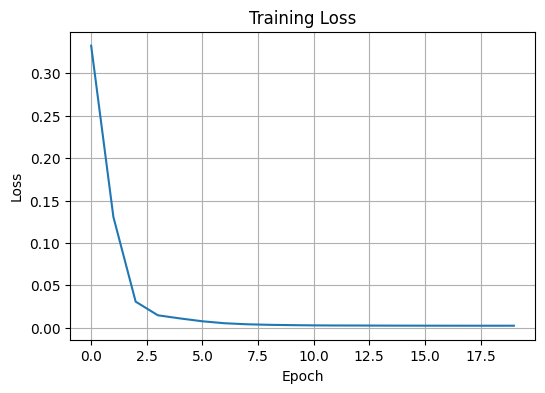

In [57]:
plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

# Evaluation and Waveform Reconstruction

The trained model reconstructs denoised waveforms from noisy spike-coded signals.

Evaluation metrics:
- Noisy reconstruction MSE
- Denoised reconstruction MSE

In [60]:
model.eval()

with torch.no_grad():

    noisy_ans, clean_ans, clean_original = next(iter(loader))


    # ========================================================
    # SPIKE ENCODING
    # ========================================================

    spk = spikegen.rate(
        noisy_ans,
        num_steps=num_steps
    )

    # ========================================================
    # PREDICTION
    # ========================================================

    pred_clean_ans = model(spk)

    pred_clean_ans = torch.clamp(
        pred_clean_ans,
        0,
        1
    )

    # ========================================================
    # INVERSE ANSCOMBE
    # ========================================================

    pred_clean = inverse_anscombe(
        pred_clean_ans * 3.0
    )

    pred_clean = torch.clamp(
        pred_clean,
        0,
        1
    )

    noisy_reconstructed = inverse_anscombe(
        noisy_ans * 3.0
    )

    noisy_reconstructed = torch.clamp(
        noisy_reconstructed,
        0,
        1
    )

    # ========================================================
    # METRICS
    # ========================================================

    mse_noisy = F.mse_loss(
        noisy_reconstructed,
        clean_original
    )

    mse_denoised = F.mse_loss(
        pred_clean,
        clean_original
    )

print("Noisy MSE:", mse_noisy.item())

print("Denoised MSE:", mse_denoised.item())

Noisy MSE: 0.02604292891919613
Denoised MSE: 0.017685191705822945


# Waveform Visualization

The following plots compare:
- Original waveform
- Noisy waveform
- Reconstructed denoised waveform

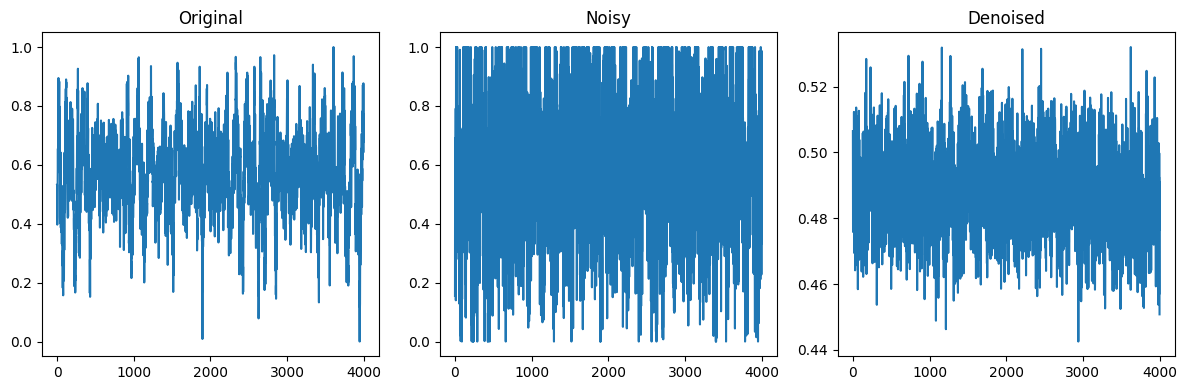

In [61]:
orig = clean_original[0].cpu().numpy()

noisy_wave = noisy_reconstructed[0].cpu().numpy()

denoised = pred_clean[0].cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)

plt.plot(orig)

plt.title("Original")

plt.subplot(1,3,2)

plt.plot(noisy_wave)

plt.title("Noisy")

plt.subplot(1,3,3)

plt.plot(denoised)

plt.title("Denoised")

plt.tight_layout()

plt.show()

# Save Reconstructed Audio

The denoised waveform is converted back into audio format and saved locally.

In [62]:
generated = (denoised * 2) - 1

sf.write(
    "generated_audio.wav",
    generated,
    sr
)

print("Generated audio saved!")

Generated audio saved!
